# Time Series Data Analysis for Civil Engineers
## A Hands-On Tutorial with NumPy and Pandas

**Duration:** 90 minutes | **Level:** Beginner | **Prerequisites:** Python basics, functions, libraries

---

### What you will learn
- Use **NumPy** to work with numerical arrays from sensor data
- Use **Pandas** to create and manipulate **time series** data
- Index, slice, resample, and compute rolling statistics on time-indexed data
- Detect and handle missing data: a common issue in real sensor networks

### Why does this matter for civil engineers?
Modern infrastructure generates data continuously:
- **Traffic counters** record vehicle counts every hour on highways and bridges
- **Structural sensors** measure strain, vibration, and displacement in real time
- **Weather stations** record temperature, wind, and rainfall around the clock

Knowing how to load, clean, and analyse this data is a valuable and increasingly expected skill for civil engineers.

| Section | Topic | Time |
|---------|-------|------|
| 1 | NumPy Basics | 10 min |
| 2 | Pandas Series & Datetime Index | 10 min |
| 3 | Indexing and Slicing by Time | 10 min |
| 4 | Resampling and Rolling Statistics | 10 min |
| 5 | Missing Data | 5 min |
| 6 | **Hackathon** | 45–60 min |

In [2]:
# Run this cell first — it imports the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 20)
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Section 1 — NumPy Basics
*Estimated time: 10 minutes*

NumPy (Numerical Python) is the foundation of data analysis in Python.
It provides the **array** — a fast, efficient container for numbers.

Think of a NumPy array as a column of numbers in a spreadsheet, but much faster to work with when doing maths.

### 1.1 Creating Arrays

We create a NumPy array with `np.array(...)` and pass in a list of numbers.

In [ ]:
# Strain readings from a bridge sensor over 10 seconds (unit: microstrain, με)
strain = np.array([120, 135, 128, 142, 139, 155, 148, 162, 170, 145])

print("Strain readings:", strain)
print("Type:  ", type(strain))
print("Shape: ", strain.shape)   # (10,) = 1-dimensional array with 10 elements

### 1.2 Basic Arithmetic

You can apply maths to the **entire array at once** — no loops needed.
NumPy handles it element-by-element automatically.

In [ ]:
# Convert microstrain → millistrain (divide all values by 1000)
strain_ms = strain / 1000
print("In millistrain:", strain_ms)

# Summary statistics
print("\nMean:", np.mean(strain))
print("Max: ", np.max(strain))
print("Min: ", np.min(strain))
print("Std: ", np.std(strain).round(2))

### 1.3 Indexing and Slicing

Access individual elements or sub-arrays using square brackets `[]`.

> **Remember:** Python indexing starts at **0**, not 1.

In [ ]:
# First reading (index 0)
print("First reading:  ", strain[0])

# Last reading (index -1)
print("Last reading:   ", strain[-1])

# Elements from index 2 up to (but not including) index 5
print("Index 2 to 4:   ", strain[2:5])

# Every second reading
print("Every 2nd:      ", strain[::2])

---
### Exercise 1 — NumPy Basics

Wind speed measurements (m/s) were recorded by a sensor on a tall building:

`[8.2, 9.1, 7.5, 11.3, 10.8, 13.2, 12.1, 9.8, 8.7, 14.5]`

**Tasks:**
- **(a)** Create a NumPy array called `wind_speed`
- **(b)** Print the **maximum** wind speed
- **(c)** Print the **last 3** readings

In [ ]:
# (a) Create the array
wind_speed = # YOUR CODE HERE

# (b) Maximum wind speed
# YOUR CODE HERE

# (c) Last 3 readings
# YOUR CODE HERE

In [ ]:
# ✅ SOLUTION — Exercise 1

# (a) Create the array
wind_speed = np.array([8.2, 9.1, 7.5, 11.3, 10.8, 13.2, 12.1, 9.8, 8.7, 14.5])

# (b) Maximum wind speed
print("Max wind speed:", np.max(wind_speed), "m/s")

# (c) Last 3 readings
print("Last 3 readings:", wind_speed[-3:])

---
## Section 2 — Pandas Series & Datetime Index
*Estimated time: 10 minutes*

Pandas is built on top of NumPy and adds **labelled indexes** to arrays.
The key object is a **Series** — an array of values with a meaningful index.

When that index contains dates and times, the Series becomes a **time series**
— and Pandas gives us powerful tools to work with it.

### 2.1 What is a Series?

In [ ]:
# Daily vehicle count on a highway for 7 days
counts = pd.Series([12400, 13100, 12800, 11200, 10900, 9800, 10200])
print(counts)

The index is just 0, 1, 2, 3 ... — not very informative.
Let's attach actual dates.

### 2.2 Creating a Datetime Index

`pd.date_range(start, periods, freq)` generates a sequence of evenly-spaced dates automatically.

| `freq` code | Meaning |
|-------------|---------|
| `'h'` | hourly |
| `'D'` | daily |
| `'W'` | weekly |
| `'ME'` | month end |

In [ ]:
# A date range: 7 days starting 1 Jan 2024, daily frequency
dates = pd.date_range(start='2024-01-01', periods=7, freq='D')
print(dates)

In [ ]:
# Attach dates as the index
traffic = pd.Series(
    [12400, 13100, 12800, 11200, 10900, 9800, 10200],
    index=dates
)
print(traffic)

### 2.3 Plotting a Time Series

A single `.plot()` call gives us a quick line chart.

In [ ]:
traffic.plot(
    title='Daily Traffic Count — Highway A1',
    ylabel='Vehicles/day',
    xlabel='Date',
    figsize=(8, 3),
    marker='o'
)
plt.tight_layout()
plt.show()

---
### Exercise 2 — Pandas Series & Datetime Index

Daily rainfall (mm) was recorded at a construction site for 10 days:

`[0.0, 2.3, 5.1, 0.0, 0.0, 8.7, 12.4, 3.2, 0.0, 1.5]`

Starting date: **2024-03-01**

**Tasks:**
- **(a)** Create the datetime index (10 days, daily frequency, starting 2024-03-01)
- **(b)** Create the Series with that index
- **(c)** Plot it

In [ ]:
rainfall_data = [0.0, 2.3, 5.1, 0.0, 0.0, 8.7, 12.4, 3.2, 0.0, 1.5]

# (a) Create the datetime index
dates_rain = # YOUR CODE HERE

# (b) Create the Series
rainfall = # YOUR CODE HERE

# (c) Plot it
# YOUR CODE HERE

In [ ]:
# ✅ SOLUTION — Exercise 2

rainfall_data = [0.0, 2.3, 5.1, 0.0, 0.0, 8.7, 12.4, 3.2, 0.0, 1.5]

# (a) Create the datetime index
dates_rain = pd.date_range(start='2024-03-01', periods=10, freq='D')

# (b) Create the Series
rainfall = pd.Series(rainfall_data, index=dates_rain)

# (c) Plot it
rainfall.plot(
    title='Daily Rainfall — Construction Site',
    ylabel='Rainfall (mm)',
    xlabel='Date',
    figsize=(8, 3),
    marker='o'
)
plt.tight_layout()
plt.show()

---
## Section 3 — Indexing and Slicing by Time
*Estimated time: 10 minutes*

One of the most powerful features of a time-indexed Series is that you can
select data using **date strings** — just like slicing a list, but with dates.

First, let's create a more realistic dataset:
**hourly traffic counts for January 2024**.
We simulate a realistic daily pattern with morning and evening peaks.

In [3]:
# Generate hourly traffic data for January 2024 (744 hours = 31 days × 24 hours)
np.random.seed(42)
dates_jan = pd.date_range(start='2024-01-01', periods=744, freq='h')

# Simulate a realistic daily pattern: peaks at 8am and 5pm
hour_of_day  = np.array([d.hour for d in dates_jan])
morning_peak = 400 * np.exp(-0.5 * ((hour_of_day - 8)  / 2) ** 2)
evening_peak = 350 * np.exp(-0.5 * ((hour_of_day - 17) / 2) ** 2)
noise        = np.random.normal(0, 30, 744)

traffic_jan = pd.Series(
    np.maximum(50, 80 + morning_peak + evening_peak + noise).astype(int),
    index=dates_jan
)

print(f"Series length: {len(traffic_jan)} records")
print(traffic_jan.head(6))

Series length: 744 records
2024-01-01 00:00:00     95
2024-01-01 01:00:00     76
2024-01-01 02:00:00    103
2024-01-01 03:00:00    143
2024-01-01 04:00:00    127
2024-01-01 05:00:00    202
Freq: h, dtype: int64


### 3.1 Selecting by a Single Date

Pass a date string to `.loc[]` to select all readings for that day.

In [4]:
# All hourly readings for January 15
jan15 = traffic_jan.loc['2024-01-15']
print(jan15)

2024-01-15 00:00:00     55
2024-01-15 01:00:00     71
2024-01-15 02:00:00     96
2024-01-15 03:00:00     80
2024-01-15 04:00:00    109
                      ... 
2024-01-15 19:00:00    262
2024-01-15 20:00:00    193
2024-01-15 21:00:00    118
2024-01-15 22:00:00    105
2024-01-15 23:00:00     59
Freq: h, Length: 24, dtype: int64


In [5]:
# A specific hour: January 15 at 8am
print(traffic_jan.loc['2024-01-15 08:00'])

465


### 3.2 Selecting a Date Range

Use a slice `'start':'end'` inside `.loc[]` to select a range.
Both endpoints are **included**.

In [6]:
# First week of January
first_week = traffic_jan.loc['2024-01-01':'2024-01-07']
print(f"Records in first week: {len(first_week)}")
print(first_week.head(6))

Records in first week: 168
2024-01-01 00:00:00     95
2024-01-01 01:00:00     76
2024-01-01 02:00:00    103
2024-01-01 03:00:00    143
2024-01-01 04:00:00    127
2024-01-01 05:00:00    202
Freq: h, dtype: int64


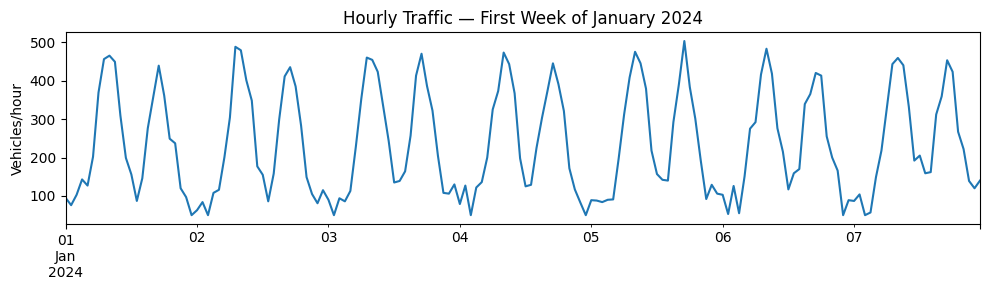

In [7]:
# Plot the first week
first_week.plot(
    title='Hourly Traffic — First Week of January 2024',
    ylabel='Vehicles/hour',
    figsize=(10, 3)
)
plt.tight_layout()
plt.show()

---
### Exercise 3 — Indexing and Slicing by Time

Using the `traffic_jan` Series you created above:

**Tasks:**
- **(a)** Extract data for **January 10–14** (Monday to Friday)
- **(b)** Print the number of records in that slice
- **(c)** Print the **maximum** hourly traffic during that week

In [ ]:
# (a) Extract Jan 10–14
working_week = # YOUR CODE HERE

# (b) Number of records
# YOUR CODE HERE

# (c) Maximum hourly traffic
# YOUR CODE HERE

In [ ]:
# ✅ SOLUTION — Exercise 3

# (a) Extract Jan 10–14
working_week = traffic_jan.loc['2024-01-10':'2024-01-14']

# (b) Number of records
print(f"Records: {len(working_week)}")

# (c) Maximum hourly traffic
print(f"Max hourly traffic: {working_week.max()} vehicles/hour")

---
## Section 4 — Resampling and Rolling Statistics
*Estimated time: 10 minutes*

Sensor data is often recorded at high frequency (every second, minute, or hour).
To see broader trends, we need to **aggregate** it to a lower frequency.

- **Resampling** = changing the time frequency (e.g., hourly → daily)
- **Rolling statistics** = computing a metric over a sliding window (e.g., 7-day moving average)

### 4.1 Resampling

`.resample(freq)` groups the data by a new time frequency.
You then apply an aggregation function: `.sum()`, `.mean()`, `.max()`, `.min()`.

In [ ]:
# Daily total traffic (sum all hourly counts per day)
daily_traffic = traffic_jan.resample('D').sum()
print(daily_traffic)

In [ ]:
daily_traffic.plot(
    title='Daily Total Traffic — January 2024',
    ylabel='Total vehicles/day',
    figsize=(10, 3),
    marker='o'
)
plt.tight_layout()
plt.show()

### 4.2 Rolling Statistics

`.rolling(window)` computes a statistic over a sliding window of `window` time steps.
It is widely used to **smooth noisy data** and **reveal trends**.

> The first `window - 1` values will be `NaN` because there are not enough previous values yet.

In [ ]:
# 7-day rolling average of daily traffic
rolling_7day = daily_traffic.rolling(window=7).mean()

# Plot original + rolling average
fig, ax = plt.subplots(figsize=(10, 3))
daily_traffic.plot(ax=ax, alpha=0.5, label='Daily total')
rolling_7day.plot(ax=ax, color='red', linewidth=2, label='7-day rolling avg')
ax.set_title('Daily Traffic with 7-day Rolling Average — January 2024')
ax.set_ylabel('Vehicles/day')
ax.legend()
plt.tight_layout()
plt.show()

---
### Exercise 4 — Resampling and Rolling Statistics

Still using `traffic_jan`:

**Tasks:**
- **(a)** Compute the **daily maximum** hourly traffic (hint: `.resample('D').max()`)
- **(b)** Compute the **3-day rolling mean** of that daily maximum
- **(c)** Plot both on the same figure with clear labels

In [ ]:
# (a) Daily maximum hourly traffic
daily_max = # YOUR CODE HERE

# (b) 3-day rolling mean
rolling_3day = # YOUR CODE HERE

# (c) Plot both
fig, ax = plt.subplots(figsize=(10, 3))
# YOUR CODE HERE  ← plot daily_max
# YOUR CODE HERE  ← plot rolling_3day
ax.set_title('Daily Peak Traffic with 3-day Rolling Average')
ax.set_ylabel('Max vehicles/hour')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ✅ SOLUTION — Exercise 4

# (a) Daily maximum hourly traffic
daily_max = traffic_jan.resample('D').max()

# (b) 3-day rolling mean
rolling_3day = daily_max.rolling(window=3).mean()

# (c) Plot both
fig, ax = plt.subplots(figsize=(10, 3))
daily_max.plot(ax=ax, alpha=0.5, label='Daily max', color='steelblue')
rolling_3day.plot(ax=ax, color='red', linewidth=2, label='3-day rolling avg')
ax.set_title('Daily Peak Traffic with 3-day Rolling Average')
ax.set_ylabel('Max vehicles/hour')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 5 — Missing Data in Time Series
*Estimated time: 5 minutes*

Real sensor data always has gaps: sensors go offline, data transmission fails,
readings get corrupted. In Pandas, missing values are represented as `NaN` (Not a Number).

It is important to detect and handle them **before** doing any analysis.

### 5.1 Detecting Missing Data

In [ ]:
# Bridge deck deflection sensor (mm) — 14 daily readings, some are missing
sensor_dates  = pd.date_range(start='2024-02-01', periods=14, freq='D')
sensor_values = [2.1, 2.4, np.nan, 2.8, np.nan, np.nan,
                 3.2, 3.0, 2.9,    np.nan, 2.7,  2.5, 2.6, 2.8]

deflection = pd.Series(sensor_values, index=sensor_dates)
print(deflection)

In [ ]:
# Check for missing values
print("Missing?\n", deflection.isnull())
print(f"\nTotal missing: {deflection.isnull().sum()} out of {len(deflection)}")

### 5.2 Filling Missing Data

Three common strategies:

| Method | Code | When to use |
|--------|------|-------------|
| Fill with a constant | `.fillna(value)` | When you know the default (e.g., 0 for rainfall) |
| Forward fill | `.ffill()` | Carry the last known value forward |
| Linear interpolation | `.interpolate()` | Estimate by drawing a straight line between neighbours |

In [ ]:
# Method 1: Fill with the series mean
filled_mean = deflection.fillna(deflection.mean())
print("Filled with mean:\n", filled_mean)

In [ ]:
# Method 2: Linear interpolation (usually best for sensor data)
filled_interp = deflection.interpolate(method='linear')
print("Interpolated:\n", filled_interp)

In [ ]:
# Visualise: original vs interpolated
fig, ax = plt.subplots(figsize=(10, 3))
deflection.plot(ax=ax, marker='o', label='Original (with gaps)', color='blue')
filled_interp.plot(ax=ax, marker='x', linestyle='--', label='Interpolated', color='red')
ax.set_title('Bridge Deck Deflection — Original vs Interpolated')
ax.set_ylabel('Deflection (mm)')
ax.legend()
plt.tight_layout()
plt.show()

---
### Exercise 5 — Missing Data

Using the `deflection` Series:

**Tasks:**
- **(a)** How many missing values are there?
- **(b)** Fill missing values using **forward fill** (`.ffill()`)
- **(c)** Print the result

In [ ]:
# (a) Count missing values
# YOUR CODE HERE

# (b) Forward fill
filled_ffill = # YOUR CODE HERE

# (c) Print result
# YOUR CODE HERE

In [ ]:
# ✅ SOLUTION — Exercise 5

# (a) Count missing values
print(f"Missing values: {deflection.isnull().sum()}")

# (b) Forward fill
filled_ffill = deflection.ffill()

# (c) Print result
print(filled_ffill)

---
# Hackathon — Bridge Monitoring Analysis
*Estimated time: 45–60 minutes*

---

### Scenario

You are a data analyst working for a transport authority.
A major highway bridge has been equipped with two monitoring systems:

1. A **traffic counter** — records the number of vehicles passing per hour
2. A **deck temperature sensor** — records bridge deck surface temperature in °C

You have **one full year of hourly data (2023)**.
Some readings are missing due to scheduled sensor maintenance.

Your job is to analyse this data and answer questions from the bridge management team.

---

### Instructions
- Each task has a blank code cell — fill in your code.
- A solution cell follows each task — try first before looking!
- Tasks get progressively harder.

---

### Generate the Dataset

Run the cell below to create your dataset.
You do not need to understand every line — just run it and move on.

In [ ]:
np.random.seed(2024)
n_hours     = 8760   # 365 days × 24 hours
dates_2023  = pd.date_range(start='2023-01-01', periods=n_hours, freq='h')

# --- Traffic pattern ---
hour_of_day  = np.array([d.hour      for d in dates_2023])
day_of_week  = np.array([d.dayofweek for d in dates_2023])   # 0=Mon, 6=Sun

morning_peak   = 500 * np.exp(-0.5 * ((hour_of_day - 8)  / 1.5) ** 2)
evening_peak   = 450 * np.exp(-0.5 * ((hour_of_day - 17) / 1.5) ** 2)
weekend_factor = np.where(day_of_week >= 5, 0.55, 1.0)

traffic_signal = (80 + morning_peak + evening_peak) * weekend_factor
traffic_raw    = np.maximum(10, traffic_signal + np.random.normal(0, 25, n_hours)).astype(float)

# --- Temperature pattern ---
day_of_year = np.array([d.dayofyear for d in dates_2023])
seasonal    = 12 * np.sin(2 * np.pi * (day_of_year - 80) / 365)   # warm summer, cold winter
diurnal     =  6 * np.sin(2 * np.pi * (hour_of_day  - 6) / 24)    # warm afternoon, cool night
temp_raw    = np.round(13 + seasonal + diurnal + np.random.normal(0, 1.5, n_hours), 1)

# --- Introduce missing values (~3%) ---
for arr in [traffic_raw, temp_raw]:
    idx = np.random.choice(n_hours, size=int(0.03 * n_hours), replace=False)
    arr[idx] = np.nan

# --- Create Series ---
traffic_2023 = pd.Series(traffic_raw, index=dates_2023, name='vehicles_per_hour')
temp_2023    = pd.Series(temp_raw,    index=dates_2023, name='deck_temp_C')

print("Dataset ready!")
print(f"  Traffic:     {len(traffic_2023):,} hourly records  |  Missing: {traffic_2023.isnull().sum()}")
print(f"  Temperature: {len(temp_2023):,} hourly records  |  Missing: {temp_2023.isnull().sum()}")

---
### Task 1 — Inspect the Data *(Easy)*

Before any analysis, always start by understanding your data.

**Tasks:**
- **(a)** Print the **first 5 readings** of `temp_2023`
- **(b)** Print the **total number of missing values** in `traffic_2023`
- **(c)** Print the **overall mean and maximum** of `traffic_2023`
  *(Pandas automatically ignores NaN in `.mean()` and `.max()`)*

In [ ]:
# (a) First 5 temperature readings
# YOUR CODE HERE

# (b) Missing values in traffic
# YOUR CODE HERE

# (c) Mean and max traffic
# YOUR CODE HERE

In [ ]:
# ✅ SOLUTION — Task 1

# (a) First 5 temperature readings
print(temp_2023.head())

# (b) Missing values in traffic
print(f"Missing traffic values: {traffic_2023.isnull().sum()}")

# (c) Mean and max traffic
print(f"Mean traffic: {traffic_2023.mean():.0f} vehicles/hour")
print(f"Max traffic:  {traffic_2023.max():.0f} vehicles/hour")

---
### Task 2 — Extract and Plot Summer Traffic *(Easy–Medium)*

The bridge team wants to understand traffic patterns during summer.

**Tasks:**
- **(a)** Slice `traffic_2023` to extract **summer data** (1 June – 31 August)
- **(b)** Resample to **daily totals** (sum of all hourly counts per day)
- **(c)** Plot the daily totals with a clear title and axis labels

In [ ]:
# (a) Extract summer traffic
summer_traffic = # YOUR CODE HERE

# (b) Daily totals
summer_daily = # YOUR CODE HERE

# (c) Plot
# YOUR CODE HERE

In [ ]:
# ✅ SOLUTION — Task 2

# (a) Extract summer traffic
summer_traffic = traffic_2023.loc['2023-06-01':'2023-08-31']

# (b) Daily totals
summer_daily = summer_traffic.resample('D').sum()

# (c) Plot
summer_daily.plot(
    title='Daily Total Traffic — Summer 2023',
    ylabel='Vehicles/day',
    xlabel='Date',
    figsize=(10, 3)
)
plt.tight_layout()
plt.show()

---
### Task 3 — Monthly Average Temperature *(Medium)*

The team wants to see how bridge deck temperature varies across the year,
but there are missing values to handle first.

**Tasks:**
- **(a)** Fill missing values in `temp_2023` using **linear interpolation**
- **(b)** Resample to **monthly averages** (hint: use `freq='ME'`)
- **(c)** Print the result and plot it with markers (`marker='o'`)

In [ ]:
# (a) Fill missing values
temp_filled = # YOUR CODE HERE

# (b) Monthly averages
temp_monthly = # YOUR CODE HERE

# (c) Print and plot
print(temp_monthly.round(1))
# YOUR CODE HERE

In [ ]:
# ✅ SOLUTION — Task 3

# (a) Fill missing values
temp_filled = temp_2023.interpolate(method='linear')

# (b) Monthly averages
temp_monthly = temp_filled.resample('ME').mean().round(1)

# (c) Print and plot
print(temp_monthly)
temp_monthly.plot(
    title='Monthly Average Bridge Deck Temperature — 2023',
    ylabel='Temperature (°C)',
    figsize=(8, 3),
    marker='o'
)
plt.tight_layout()
plt.show()

---
### Task 4 — Annual Traffic Trend *(Medium–Hard)*

The team wants to identify long-term trends in traffic throughout the year.

**Tasks:**
- **(a)** Fill missing values in `traffic_2023` using **forward fill** (`.ffill()`)
- **(b)** Resample to **daily total traffic**
- **(c)** Compute the **30-day rolling average**
- **(d)** Plot daily traffic (semi-transparent, `alpha=0.4`) and the rolling average
  (solid red line, `linewidth=2`) on the **same figure**

In [ ]:
# (a) Fill missing traffic values
traffic_filled = # YOUR CODE HERE

# (b) Daily totals
traffic_daily = # YOUR CODE HERE

# (c) 30-day rolling average
rolling_30 = # YOUR CODE HERE

# (d) Plot
fig, ax = plt.subplots(figsize=(12, 4))
# YOUR CODE HERE  ← plot traffic_daily
# YOUR CODE HERE  ← plot rolling_30
ax.set_title('Annual Traffic with 30-day Rolling Average — 2023')
ax.set_ylabel('Vehicles/day')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ✅ SOLUTION — Task 4

# (a) Fill missing traffic values
traffic_filled = traffic_2023.ffill()

# (b) Daily totals
traffic_daily = traffic_filled.resample('D').sum()

# (c) 30-day rolling average
rolling_30 = traffic_daily.rolling(window=30).mean()

# (d) Plot
fig, ax = plt.subplots(figsize=(12, 4))
traffic_daily.plot(ax=ax, alpha=0.4, label='Daily total', color='steelblue')
rolling_30.plot(ax=ax, color='red', linewidth=2, label='30-day rolling avg')
ax.set_title('Annual Traffic with 30-day Rolling Average — 2023')
ax.set_ylabel('Vehicles/day')
ax.legend()
plt.tight_layout()
plt.show()

---
### Task 5 — Find the Busiest Week *(Hard)*

The team needs to plan a maintenance window and wants to **avoid the busiest week of the year**.

**Tasks:**
- **(a)** Using `traffic_daily` from Task 4, resample to **weekly totals**
  (hint: `freq='W'`)
- **(b)** Find the week with the **highest total traffic**
  (hint: `.idxmax()` returns the index label of the maximum value)
- **(c)** Print the date of that week and its total vehicle count
- **(d)** Using `traffic_filled` (hourly), extract a **±3 day window** around that date and plot it

*Hint for (d):* `pd.Timedelta(days=3)` lets you add or subtract days from a date.

In [ ]:
# (a) Weekly totals
weekly_traffic = # YOUR CODE HERE

# (b) Date of the busiest week
busiest_week_date = # YOUR CODE HERE

# (c) Print date and total
# YOUR CODE HERE

# (d) Slice ±3 days and plot
start_date     = busiest_week_date - pd.Timedelta(days=3)
end_date       = busiest_week_date + pd.Timedelta(days=3)
busiest_period = # YOUR CODE HERE

# YOUR CODE HERE  ← plot busiest_period

In [ ]:
# ✅ SOLUTION — Task 5

# (a) Weekly totals
weekly_traffic = traffic_daily.resample('W').sum()

# (b) Date of the busiest week
busiest_week_date = weekly_traffic.idxmax()

# (c) Print date and total
print(f"Busiest week ending: {busiest_week_date.date()}")
print(f"Total vehicles:      {weekly_traffic[busiest_week_date]:,.0f}")

# (d) Slice ±3 days and plot
start_date     = busiest_week_date - pd.Timedelta(days=3)
end_date       = busiest_week_date + pd.Timedelta(days=3)
busiest_period = traffic_filled.loc[start_date:end_date]

busiest_period.plot(
    title=f'Hourly Traffic — Busiest Week ({start_date.date()} to {end_date.date()})',
    ylabel='Vehicles/hour',
    figsize=(10, 3)
)
plt.tight_layout()
plt.show()

---
## Well Done!

You have completed the tutorial. Here is a summary of what you have learned:

| Skill | What you can now do |
|-------|---------------------|
| **NumPy** | Create arrays, do arithmetic, index and slice |
| **Pandas Series** | Build time-indexed Series, plot them |
| **Time indexing** | Select data by date string and date range with `.loc` |
| **Resampling** | Change frequency: hourly → daily → monthly |
| **Rolling stats** | Compute moving averages to smooth noise and reveal trends |
| **Missing data** | Detect `NaN`, fill with `.ffill()` or `.interpolate()` |

---

### Links for selfstudy

[Introduction to Pandas and NumPy](https://www.codecademy.com/article/introduction-to-numpy-and-pandas)<br>
[NumPy API reference](https://numpy.org/doc/stable/reference/generated/numpy.array.html#numpy.array)<br>
[pandas API reference](https://pandas.pydata.org/docs/reference/api/pandas.array.html)<br>

---

### What's next?

The next tutorial covers **tabular data with Pandas DataFrames** — working with
multiple columns, filtering rows, and combining datasets.
The time series skills you have learned today will apply directly there too.